In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
glori_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/analyses/cluster_glori/glori_df.clustered.pkl")

In [3]:
print(glori_df)

                genome_id    chr str        pos  m6A_level  exp_depth nearest
0       chr10:+:100186272  chr10   +  100186272   0.607143       56.0     inf
1       chr10:+:100248362  chr10   +  100248362   0.145833       48.0   101.0
2       chr10:+:100248463  chr10   +  100248463   0.157895       38.0   101.0
3       chr10:+:100248669  chr10   +  100248669   0.098361      122.0    15.0
4       chr10:+:100248684  chr10   +  100248684   0.037791      344.0    15.0
...                   ...    ...  ..        ...        ...        ...     ...
239281     chrY:-:5337980   chrY   -    5337980   0.109589       73.0    38.0
239282     chrY:-:5338018   chrY   -    5338018   0.014359      975.0     3.0
239283     chrY:-:5338021   chrY   -    5338021   0.026882      744.0     3.0
239284     chrY:-:5338107   chrY   -    5338107   0.090305      753.0    86.0
239285     chrY:-:5338514   chrY   -    5338514   0.035011      457.0   407.0

[239286 rows x 7 columns]


In [11]:
glori_df["clustered"] = glori_df["nearest"] <= 20

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


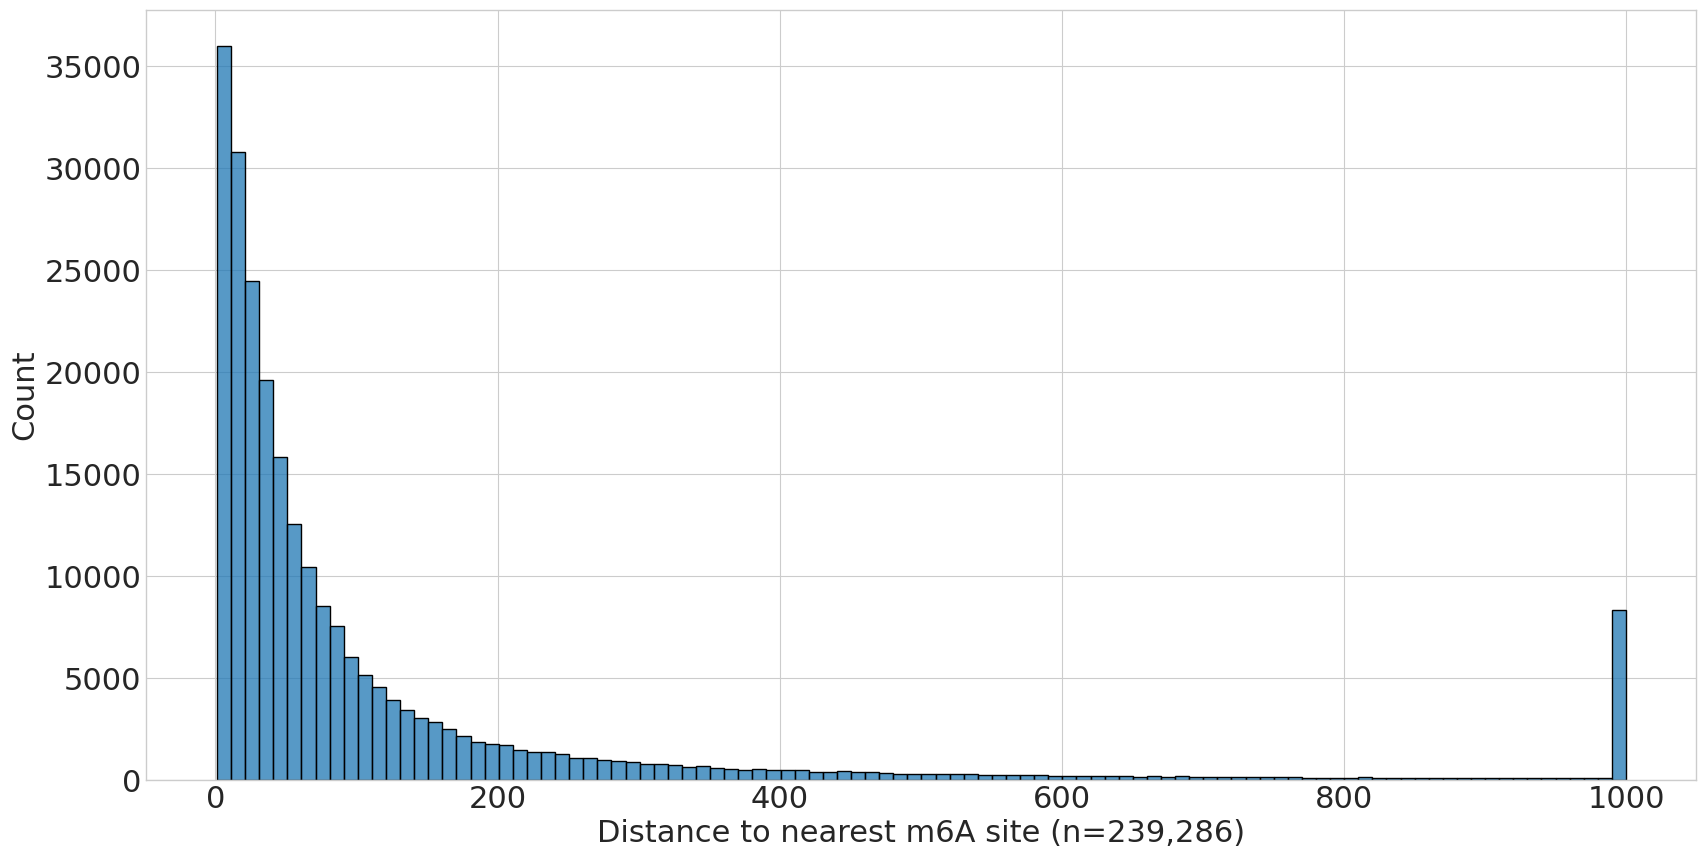

In [29]:
## 1. Plot Histogram of "nearest" column

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
sns.histplot(glori_df["nearest"].clip(0, 1000), bins=100, ax=ax)
ax.set_xlabel(f"Distance to nearest m6A site (n={len(glori_df):,})")
ax.set_ylabel("Count")
plt.show()



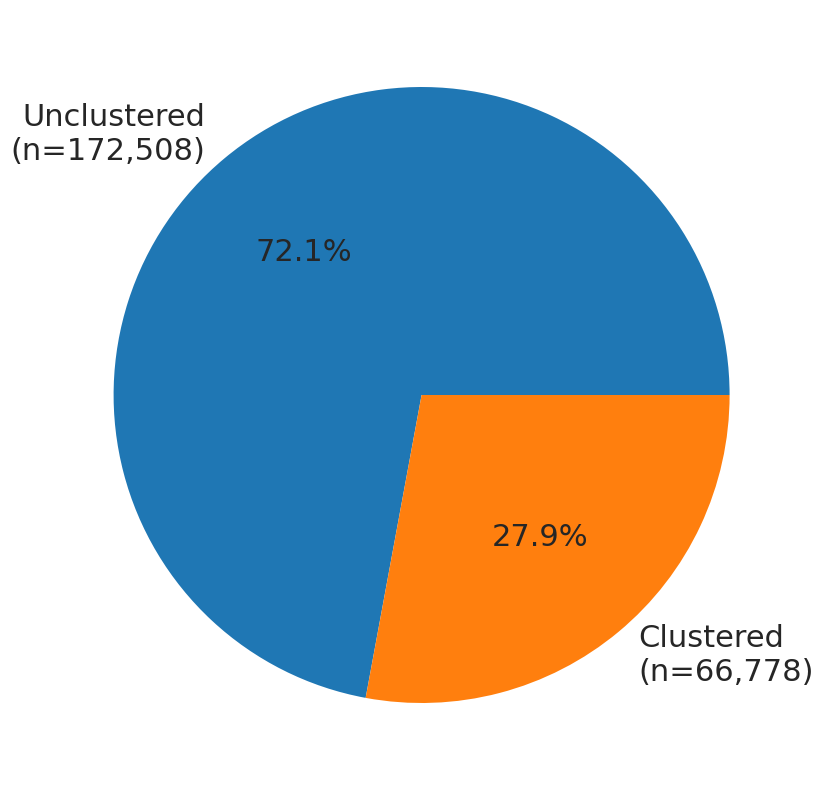

In [28]:

## 2. Plot pie chart of "clustered" column
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
clustered_count = glori_df["clustered"].value_counts()
ax.pie(clustered_count, labels=[f"Unclustered\n(n={clustered_count[False]:,})", f"Clustered\n(n={clustered_count[True]:,})"],
       autopct='%1.1f%%')
plt.show()

In [13]:
exp4_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/analyses/cluster_4exp/glori_df.clustered.pkl")

In [14]:
print(exp4_df)

               genome_id    chr str        pos nearest
0      chr10:+:100363097  chr10   +  100363097  1415.0
1      chr10:+:100364512  chr10   +  100364512  1415.0
2      chr10:+:100548246  chr10   +  100548246    79.0
3      chr10:+:100548325  chr10   +  100548325    79.0
4      chr10:+:100548599  chr10   +  100548599   274.0
...                  ...    ...  ..        ...     ...
22371    chrX:-:74592566   chrX   -   74592566    60.0
22372    chrX:-:74592932   chrX   -   74592932   366.0
22373    chrX:-:77682950   chrX   -   77682950   421.0
22374    chrX:-:77683371   chrX   -   77683371   421.0
22375    chrX:-:80676800   chrX   -   80676800     inf

[22376 rows x 5 columns]


In [15]:
exp4_df["clustered"] = exp4_df["nearest"] <= 20

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


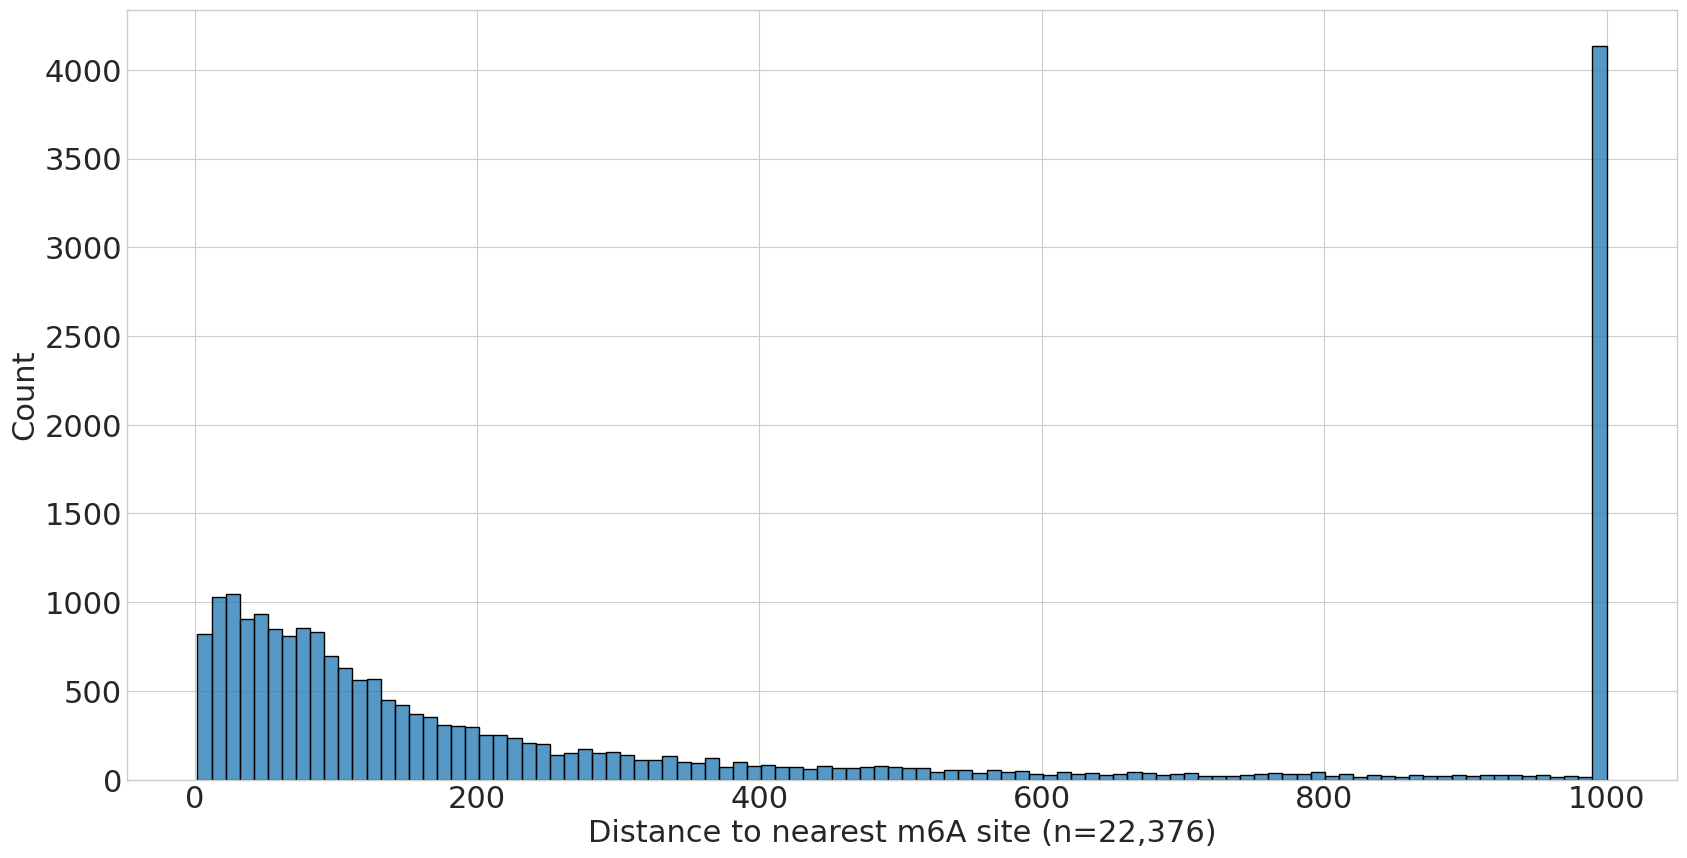

In [30]:
## 1. Plot Histogram of "nearest" column

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
sns.histplot(exp4_df["nearest"].clip(0, 1000), bins=100, ax=ax)
ax.set_xlabel(f"Distance to nearest m6A site (n={len(exp4_df):,})")
ax.set_ylabel("Count")
plt.show()


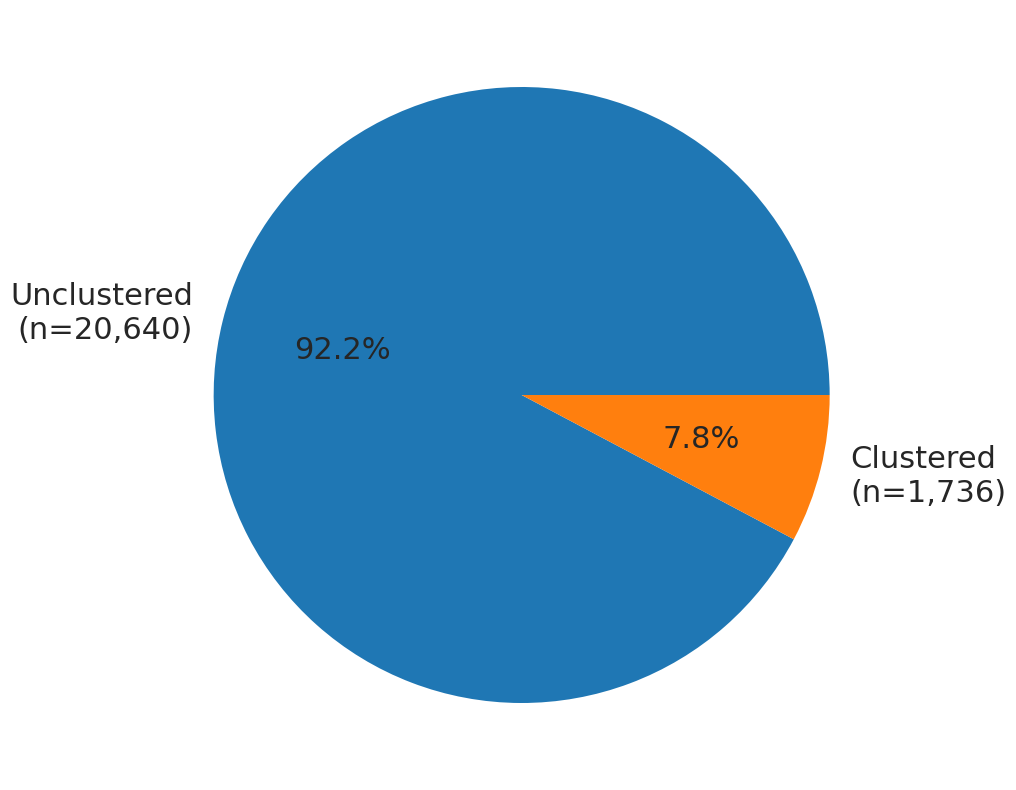

In [27]:
## 2. Plot pie chart of "clustered" column
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
clustered_count = exp4_df["clustered"].value_counts()
ax.pie(clustered_count, labels=[f"Unclustered\n(n={clustered_count[False]:,})", f"Clustered\n(n={clustered_count[True]:,})"],
       autopct='%1.1f%%')
plt.show()